# Team baselines and predictive backbone

Compare the base rate, hard-reset Elo, tuned carryover, uncertainty baseline, dynamic backbone, and contextual challengers on rolling 2024–2025 forecasts.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if not DEVELOPMENT.exists():
    raise FileNotFoundError("Pass --development to render model results")
metrics = pd.read_parquet(DEVELOPMENT / "metrics" / "team.parquet")
predictions = pd.read_parquet(DEVELOPMENT / "predictions" / "map_oof.parquet")
gates = json.loads((DEVELOPMENT / "promotion_gates.json").read_text(encoding="utf-8"))["gates"]
selection = json.loads((DEVELOPMENT / "selection.json").read_text(encoding="utf-8"))
display(metrics.sort_values("map_log_loss"))
display(pd.json_normalize(gates))
print("frozen decision:", selection["selected_config"])

,model,maps,map_log_loss,brier,calibration_intercept,calibration_slope,expected_calibration_error
0,carryover,2376,0.676884,0.242030,-0.009904,1.071743,0.011801
1,blend,2376,0.686971,0.246904,0.022326,0.845404,0.014815
2,glicko,2376,0.689658,0.247182,-0.014940,0.520124,0.068329
3,current_elo,2376,0.692376,0.249532,0.041627,0.506630,0.029977
4,constant,2376,0.693078,0.249966,0.412093,-8.183872,0.003949
5,elastic_net,2376,0.696055,0.250817,-0.041841,0.480765,0.077874
6,backbone,2376,0.697256,0.251099,-0.042236,0.467133,0.078142
7,boosted,2376,0.700741,0.252464,0.008464,0.405198,0.063751


,baseline,brier_degradation,calibration_slope_degradation,candidate,development_pass,final_holdout_pass,promoted,paired_difference.confidence,paired_difference.lower,paired_difference.mean_difference,paired_difference.resamples,paired_difference.unit,paired_difference.upper
0,current_elo,-0.007503,-0.421627,carryover,True,None,False,0.95,-0.026777,-0.015492,2000,match_id,-0.011572
1,current_elo,0.001567,0.039496,backbone,False,None,False,0.95,-0.012460,0.004880,2000,match_id,0.015700
2,backbone,-0.004195,-0.378270,blend,False,None,False,0.95,-0.018746,-0.010285,2000,match_id,0.002365


frozen decision: {'forecast_champion': 'carryover', 'rating_backbone': 'carryover', 'seed': 20260714, 'selected_carryover': {'global_weight': 0.85, 'inactivity_uncertainty_per_day': 0.18, 'initial_rating': 1000.0, 'k_factor': 32.0, 'map_update_weight': 0.55, 'margin_cap': 2.5, 'margin_power': 1.0, 'offseason_regression': 0.7, 'probability_scale': 1000.0, 'reset_yearly': False, 'time_decay_half_life_days': 360.0, 'uncertainty_probability_weight': 0.25}, 'selected_player_ablation': 'triple'}


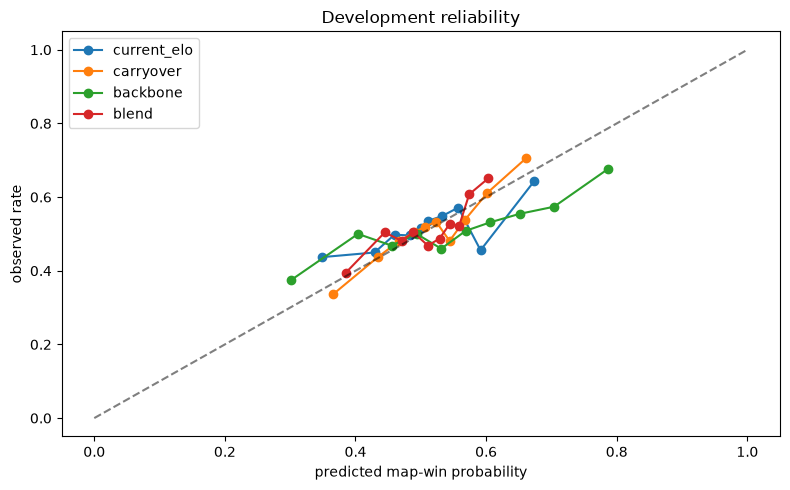

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in ("current_elo", "carryover", "backbone", "blend"):
    column = f"{model}_probability"
    if column not in predictions:
        continue
    work = predictions[[column, "team_a_won"]].dropna().copy()
    work["bin"] = pd.qcut(work[column], 10, duplicates="drop")
    reliability = work.groupby("bin", observed=True).agg(
        predicted=(column, "mean"), observed=("team_a_won", "mean"), maps=("team_a_won", "size")
    )
    ax.plot(reliability["predicted"], reliability["observed"], marker="o", label=model)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", alpha=0.5)
ax.set(xlabel="predicted map-win probability", ylabel="observed rate", title="Development reliability")
ax.legend()
plt.tight_layout()
plt.show()

Promotion requires a match-clustered paired log-loss interval below
zero, no material Brier/calibration degradation, and the same-direction
result on the untouched 2026 confirmation set.